### Pokemon API (No API Key Required)

In [7]:
import requests

In [8]:
base_url = 'https://pokeapi.co/api/v2/pokemon/'
name = 'squirtle'
name_url = base_url + name

In [9]:
response = requests.get(name_url)
if response.status_code == 200:
    data = response.json()
else:
    print(f'error: response code {response.status_code}')

In [10]:
import numpy as np
num_moves = len(data['moves'])
length = np.arange(0, num_moves, 1)

In [11]:
import numpy as np
num_moves = len(data['moves'])
length = np.arange(0, num_moves, 1)

moves = []
for num in length:
    moves.append(data['moves'][num]['move']['name'])

In [12]:
def get_moves(name):
    base_url = 'https://pokeapi.co/api/v2/pokemon/'
    name = name
    name_url = base_url + name
    response = requests.get(name_url)
    if response.status_code == 200:
        data = response.json()
    else:
        print(f'error: response code {response.status_code}')
    num_moves = len(data['moves'])
    length = np.arange(0, num_moves, 1)

    moves1 = []
    for num in length:
        moves1.append(data['moves'][num]['move']['name'])
    return moves1

In [13]:
get_moves('charmander')[:5]

['mega-punch', 'fire-punch', 'thunder-punch', 'scratch', 'swords-dance']

In [14]:
def get_moves_dict(name_list):
    moves_dict = {}
    for name in name_list:
        base_url = 'https://pokeapi.co/api/v2/pokemon/'
        name = name
        name_url = base_url + name
        response = requests.get(name_url)
        if response.status_code == 200:
            data = response.json()
        else:
            print(f'error: response code {response.status_code}')
        num_moves = len(data['moves'])
        length = np.arange(0, num_moves, 1)

        moves = []
        for num in length:
            moves.append(data['moves'][num]['move']['name'])
        moves_dict.update({f'{name}': moves})
    return moves_dict

In [15]:
moves_dict = get_moves_dict(['charmander', 'squirtle', 'bulbasaur'])
print(f'Charmander: {moves_dict['charmander'][:5]}')
print(f'Squirtle: {moves_dict['squirtle'][:5]}')
print(f'Bulbasaur: {moves_dict['bulbasaur'][:5]}')

Charmander: ['mega-punch', 'fire-punch', 'thunder-punch', 'scratch', 'swords-dance']
Squirtle: ['mega-punch', 'ice-punch', 'mega-kick', 'headbutt', 'tackle']
Bulbasaur: ['razor-wind', 'swords-dance', 'cut', 'bind', 'vine-whip']


### Alpha Vantage API

https://www.alphavantage.co/documentation/

In [16]:
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey=################'

In [17]:
response = requests.get(url)

In [18]:
data = response.json()

In [19]:
import pandas as pd
stock_df = pd.DataFrame(data['Time Series (Daily)']).transpose()

In [20]:
stock_df = stock_df.rename(columns = {'1. open':'Open', '2. high':'High', '3. low':'Low', '4. close':'Close', '5. volume':'Volume'})

In [21]:
reset_index = stock_df.reset_index()
reset_index.rename(columns = {'index':'Date'}, inplace = True)
reset_index = reset_index.astype({'Open':'float', 'High':'float','Low':'float','Close':'float','Volume':'int'})
reset_index['Date'] = pd.to_datetime(reset_index['Date'], format = 'ISO8601')

In [22]:
reset_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    100 non-null    datetime64[ns]
 1   Open    100 non-null    float64       
 2   High    100 non-null    float64       
 3   Low     100 non-null    float64       
 4   Close   100 non-null    float64       
 5   Volume  100 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 4.8 KB


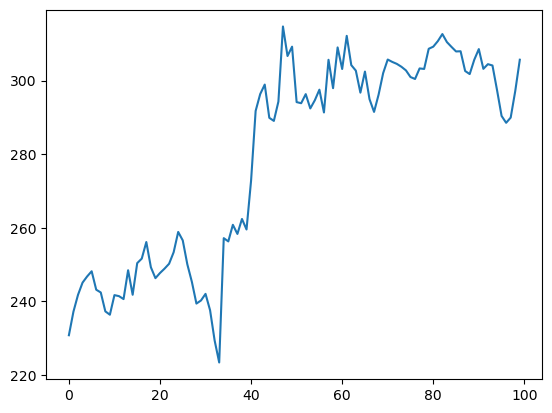

In [23]:
import matplotlib.pyplot as plt
plt.plot(reset_index['Close'])

In [24]:
reset_index[reset_index['Close'] == reset_index['Close'].min()]

,Date,Open,High,Low,Close,Volume
33,2026-02-23,254.37,255.19,220.72,223.35,19522881


### Creating a function to get stock details via Alpha Vantage API

Note: users attempting to replicate this will need thier own API key

In [36]:
import requests
import numpy as np
import pandas as pd

def get_stock_info(function, symbol, api_key):
    base_url = 'https://www.alphavantage.co/query?'
    function = f'function={function}&'
    symbol = f'symbol={symbol}&'
    api_key = f'apikey={api_key}'
    query_url = base_url + function + symbol + api_key
    response = requests.get(query_url)
    data = response.json()
    stock_df = pd.DataFrame(data['Time Series (Daily)']).transpose()
    stock_df = stock_df.rename(columns = {'1. open':'Open', '2. high':'High', '3. low':'Low', '4. close':'Close', '5. volume':'Volume'})
    reset_index = stock_df.reset_index()
    reset_index.rename(columns = {'index':'Date'}, inplace = True)
    reset_index = reset_index.astype({'Open':'float', 'High':'float','Low':'float','Close':'float','Volume':'int'})
    reset_index['Date'] = pd.to_datetime(reset_index['Date'], format = 'ISO8601')
    final_df = reset_index
    return final_df

In [40]:
AAPL_df = get_stock_info('TIME_SERIES_DAILY', 'AAPL', '################')
AAPL_df

,Date,Open,High,Low,Close,Volume
0,2026-04-10,259.980,262.1900,259.0231,260.48,31291473
1,2026-04-09,259.000,261.1200,256.0700,260.49,28121574
2,2026-04-08,258.450,259.7499,256.5300,258.90,41032772
3,2026-04-07,256.155,256.2000,245.7000,253.50,62148008
4,2026-04-06,256.510,262.1600,256.4600,258.86,29329911
...,...,...,...,...,...,...
95,2025-11-20,270.830,275.4300,265.9200,266.25,45823568
96,2025-11-19,265.525,272.2100,265.5000,268.56,40424492
97,2025-11-18,269.990,270.7100,265.3200,267.44,45677278
98,2025-11-17,268.815,270.4900,265.7300,267.46,45018260


<Axes: >

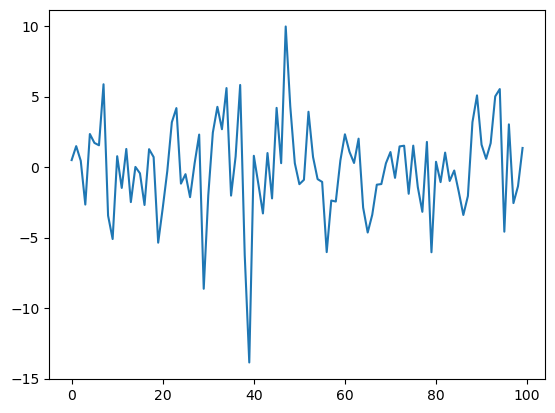

In [41]:
import seaborn as sns
AAPL_diff = AAPL_df['Close'] - AAPL_df['Open']
sns.lineplot(AAPL_diff)

In [42]:
GOOG_df = get_stock_info('TIME_SERIES_DAILY', 'GOOG', '################')
GOOG_df

,Date,Open,High,Low,Close,Volume
0,2026-04-10,318.225,319.500,314.540,315.72,11997647
1,2026-04-09,313.190,317.430,309.470,316.37,14606751
2,2026-04-08,317.830,319.390,312.705,314.74,20887530
3,2026-04-07,300.140,304.100,295.425,303.93,17317708
4,2026-04-06,294.700,298.425,293.790,297.66,10121741
...,...,...,...,...,...,...
95,2025-11-20,304.740,306.890,289.170,289.98,34801371
96,2025-11-19,287.685,304.250,287.670,292.99,43123599
97,2025-11-18,288.485,289.435,279.010,284.96,29702228
98,2025-11-17,286.400,294.520,284.230,285.60,34286093


<Axes: >

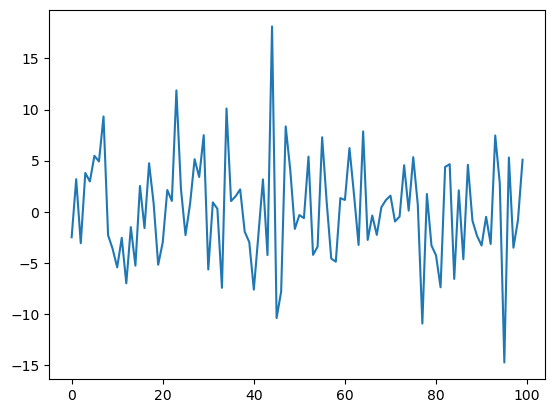

In [43]:
import seaborn as sns
GOOG_diff = GOOG_df['Close'] - GOOG_df['Open']
sns.lineplot(GOOG_diff)

### Using dickey fuller test to determine if difference between open and close are stationary

If the stock closes higher than it opens, the difference value is positive on the above graphs. The below p values indicate that according to the test, the time series are stationary. We can see no visibly seasonality or trend, and the graphs are all hovering aroudn a mean of 0. This intuitively makes sense, as if a stock closes or opens too far from the mean, traders will see it as over or undervalued and take trades accordingly, forcing the overall stock price back to the mean. This is true for the short term, but discounts more long-term price trends.

In [45]:
!pip install --quiet statsmodels
import statsmodels

In [47]:
from statsmodels.tsa.stattools import adfuller
adfuller(AAPL_diff)

(np.float64(-8.414048234357567),
 np.float64(2.0666010326694575e-13),
 0,
 99,
 {'1%': np.float64(-3.498198082189098),
  '5%': np.float64(-2.891208211860468),
  '10%': np.float64(-2.5825959973472097)},
 np.float64(461.04939717322543))

In [48]:
adfuller(GOOG_diff)

(np.float64(-8.133665621235073),
 np.float64(1.0734390399874954e-12),
 1,
 98,
 {'1%': np.float64(-3.4989097606014496),
  '5%': np.float64(-2.891516256916761),
  '10%': np.float64(-2.5827604414827157)},
 np.float64(530.7648799513308))